In [1]:
# ============================================
# NOTEBOOK 3 — Exploratory Data Analysis
# Sales Intelligence Project
# Analyst: Danish Siddiqui
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Create reports folder if not exists
os.makedirs('reports', exist_ok=True)

# Load clean data
sales = pd.read_csv('data/sales_clean.csv')
sales['date'] = pd.to_datetime(sales['date'])

print("✅ Clean data loaded successfully!")
print(f"   Shape: {sales.shape}")
print(f"\nColumns available: {list(sales.columns)}")
print(f"\nFirst 3 rows:")
print(sales.head(3).to_string())

✅ Clean data loaded successfully!
   Shape: (502, 16)

Columns available: ['order_id', 'date', 'product_id', 'region_id', 'quantity', 'unit_price', 'discount_pct', 'revenue', 'month', 'month_name', 'year', 'quarter', 'product_name', 'category', 'region_name', 'zone']

First 3 rows:
   order_id       date product_id region_id  quantity  unit_price  discount_pct  revenue  month month_name  year  quarter      product_name     category region_name   zone
0  ORD_0001 2023-01-01       P004       R06         2       35000           0.0  70000.0      1        Jan  2023        1          Tablet X  Electronics        Pune   West
1  ORD_0002 2023-01-02       P005       R04        15        2200           0.0  33000.0      1        Jan  2023        1         USB-C Hub  Accessories     Chennai  South
2  ORD_0003 2023-01-03       P003       R08         8        4500           0.0  36000.0      1        Jan  2023        1  Wireless Earbuds        Audio   Ahmedabad   West


In [2]:
# ── STEP 1: Overall Business Summary ──────────
print("=" * 50)
print("   BUSINESS PERFORMANCE SUMMARY")
print("=" * 50)

total_revenue  = sales['revenue'].sum()
total_orders   = len(sales)
avg_order_val  = sales['revenue'].mean()
total_qty      = sales['quantity'].sum()
top_product    = sales.groupby('product_name')['revenue'].sum().idxmax()
top_region     = sales.groupby('region_name')['revenue'].sum().idxmax()

print(f"\n  Total Revenue      : ₹{total_revenue:,.0f}")
print(f"  Total Orders       : {total_orders}")
print(f"  Avg Order Value    : ₹{avg_order_val:,.0f}")
print(f"  Total Units Sold   : {total_qty:,}")
print(f"  Top Product        : {top_product}")
print(f"  Top Region         : {top_region}")
print(f"\nStatistical Summary:")
print(sales[['quantity','unit_price','discount_pct','revenue']].describe().round(2))

   BUSINESS PERFORMANCE SUMMARY

  Total Revenue      : ₹134,226,220
  Total Orders       : 502
  Avg Order Value    : ₹267,383
  Total Units Sold   : 4,899
  Top Product        : Laptop Pro
  Top Region         : Delhi

Statistical Summary:
       quantity  unit_price  discount_pct     revenue
count    502.00      502.00        502.00      502.00
mean       9.76    27746.22          0.05   267382.91
std        5.55    27738.34          0.05   350669.67
min        1.00     2200.00          0.00     1980.00
25%        5.00     4500.00          0.00    31942.50
50%        9.50    12000.00          0.05    96600.00
75%       14.75    35000.00          0.10   375000.00
max       19.00    75000.00          0.15  1425000.00


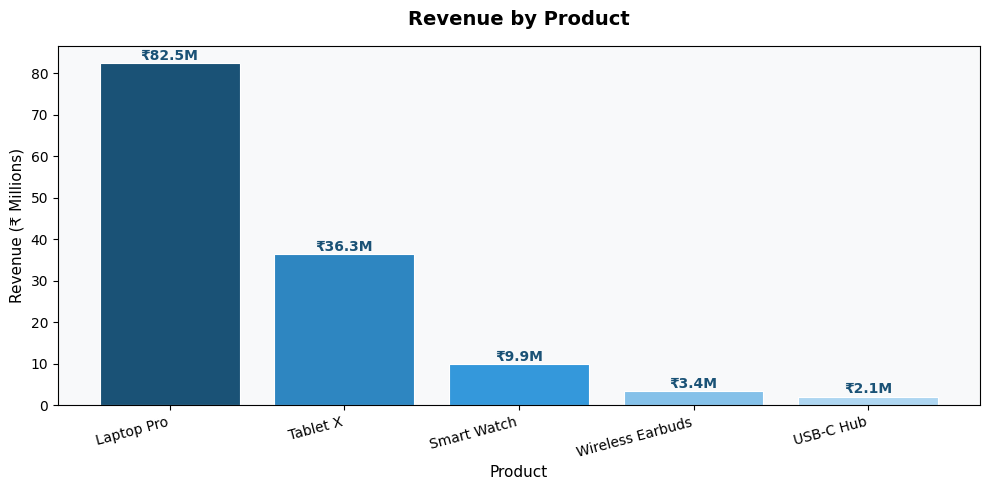

✅ Chart saved → reports/01_revenue_by_product.png


In [3]:
# ── STEP 2: Revenue by Product ────────────────
product_revenue = (sales.groupby('product_name')['revenue']
                       .sum()
                       .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(product_revenue.index, 
              product_revenue.values / 1e6,
              color=['#1A5276','#2E86C1','#3498DB','#85C1E9','#AED6F1'],
              edgecolor='white', linewidth=0.8)

# Add value labels on bars
for bar, val in zip(bars, product_revenue.values):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 0.1,
            f'₹{val/1e6:.1f}M', 
            ha='center', va='bottom', 
            fontsize=10, fontweight='bold', color='#1A5276')

ax.set_title('Revenue by Product', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Product', fontsize=11)
ax.set_ylabel('Revenue (₹ Millions)', fontsize=11)
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('white')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('reports/01_revenue_by_product.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → reports/01_revenue_by_product.png")

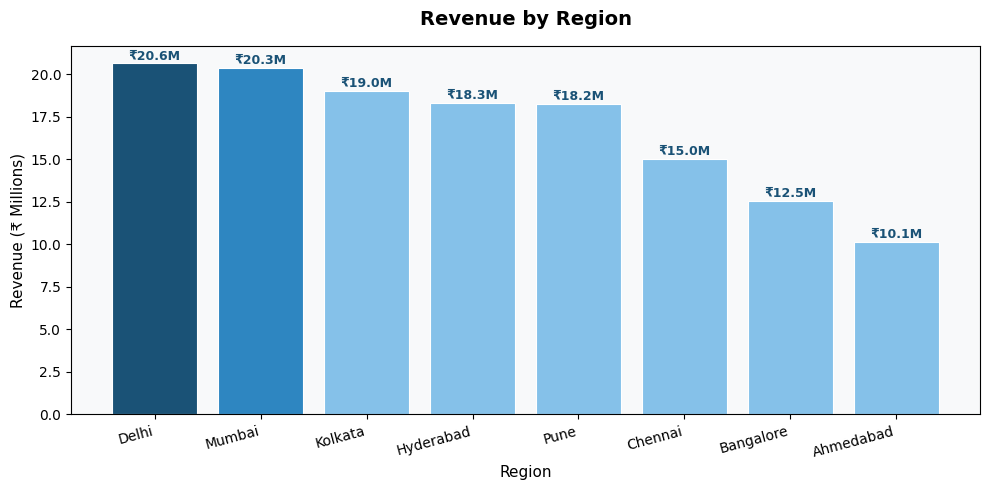

✅ Chart saved → reports/02_revenue_by_region.png


In [4]:
# ── STEP 3: Revenue by Region ─────────────────
region_revenue = (sales.groupby('region_name')['revenue']
                      .sum()
                      .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#1A5276' if i == 0 else '#2E86C1' if i == 1 else '#85C1E9' 
          for i in range(len(region_revenue))]
bars = ax.bar(region_revenue.index, 
              region_revenue.values / 1e6,
              color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, region_revenue.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'₹{val/1e6:.1f}M',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#1A5276')

ax.set_title('Revenue by Region', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Region', fontsize=11)
ax.set_ylabel('Revenue (₹ Millions)', fontsize=11)
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('white')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('reports/02_revenue_by_region.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → reports/02_revenue_by_region.png")

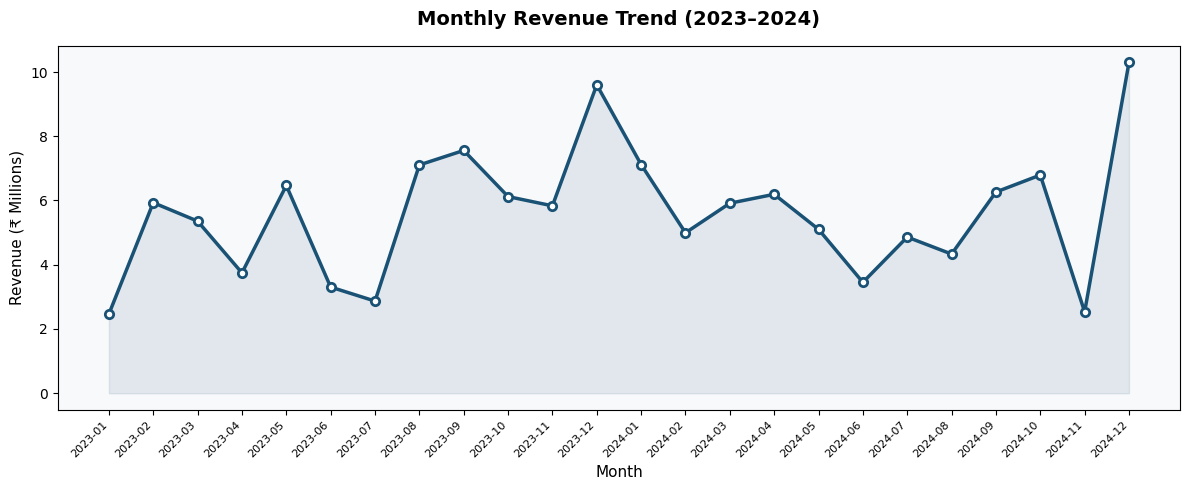

✅ Chart saved → reports/03_monthly_trend.png


In [5]:
# ── STEP 4: Monthly Revenue Trend ─────────────
monthly = (sales.groupby(['year','month'])['revenue']
               .sum()
               .reset_index())
monthly['period'] = monthly['year'].astype(str) + '-' + monthly['month'].astype(str).str.zfill(2)
monthly = monthly.sort_values('period')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly['period'], monthly['revenue'] / 1e6,
        color='#1A5276', linewidth=2.5,
        marker='o', markersize=6, markerfacecolor='white',
        markeredgecolor='#1A5276', markeredgewidth=2)

ax.fill_between(range(len(monthly)), 
                monthly['revenue'].values / 1e6,
                alpha=0.1, color='#1A5276')

ax.set_title('Monthly Revenue Trend (2023–2024)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Revenue (₹ Millions)', fontsize=11)
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('white')
plt.xticks(range(len(monthly)), monthly['period'], 
           rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('reports/03_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → reports/03_monthly_trend.png")

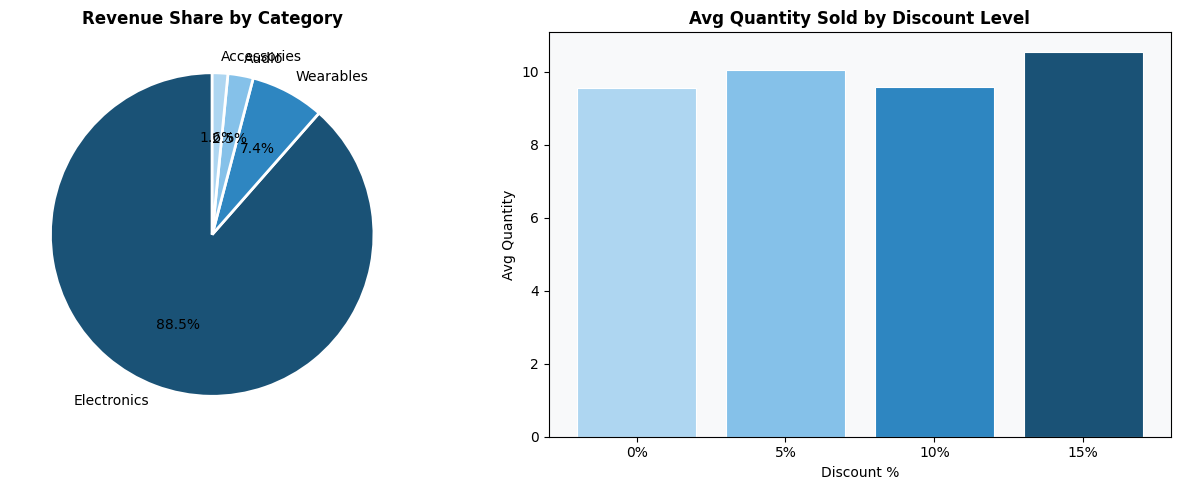

✅ Chart saved → reports/04_category_discount.png


In [6]:
# ── STEP 5: Category Revenue + Discount Impact ─
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Chart 1 — Revenue by Category
cat_rev = sales.groupby('category')['revenue'].sum().sort_values(ascending=False)
axes[0].pie(cat_rev.values, 
            labels=cat_rev.index,
            autopct='%1.1f%%',
            colors=['#1A5276','#2E86C1','#85C1E9','#AED6F1','#D6EAF8'],
            startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Revenue Share by Category', fontsize=12, fontweight='bold')

# Chart 2 — Discount vs Quantity Sold
discount_qty = sales.groupby('discount_pct')['quantity'].mean()
axes[1].bar([f"{int(d*100)}%" for d in discount_qty.index],
            discount_qty.values,
            color=['#AED6F1','#85C1E9','#2E86C1','#1A5276'],
            edgecolor='white', linewidth=0.8)
axes[1].set_title('Avg Quantity Sold by Discount Level', 
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Discount %', fontsize=10)
axes[1].set_ylabel('Avg Quantity', fontsize=10)
axes[1].set_facecolor('#F8F9FA')

fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('reports/04_category_discount.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → reports/04_category_discount.png")

In [7]:
# ── STEP 6: Print Key Insights ────────────────
print("=" * 55)
print("   KEY BUSINESS INSIGHTS — EDA SUMMARY")
print("=" * 55)

# Top 3 products
top3_products = (sales.groupby('product_name')['revenue']
                     .sum()
                     .sort_values(ascending=False)
                     .head(3))

# Top 3 regions
top3_regions = (sales.groupby('region_name')['revenue']
                    .sum()
                    .sort_values(ascending=False)
                    .head(3))

# Best month
best_month = (sales.groupby('month_name')['revenue']
                  .sum()
                  .idxmax())

# Correlation
corr_val = sales['discount_pct'].corr(sales['quantity'])

print(f"\n  TOP 3 PRODUCTS BY REVENUE:")
for i, (name, rev) in enumerate(top3_products.items(), 1):
    print(f"    {i}. {name} — ₹{rev:,.0f}")

print(f"\n  TOP 3 REGIONS BY REVENUE:")
for i, (name, rev) in enumerate(top3_regions.items(), 1):
    print(f"    {i}. {name} — ₹{rev:,.0f}")

print(f"\n  BEST PERFORMING MONTH : {best_month}")
print(f"  DISCOUNT vs QUANTITY  : correlation = {corr_val:.2f}")

if corr_val > 0:
    print(f"  → Higher discounts lead to MORE units sold")
else:
    print(f"  → Discount has minimal impact on quantity")

print(f"\n  TOTAL CHARTS SAVED    : 4 charts in reports/ folder")
print("\n" + "=" * 55)
print("   EDA COMPLETE ✅")
print("=" * 55)

   KEY BUSINESS INSIGHTS — EDA SUMMARY

  TOP 3 PRODUCTS BY REVENUE:
    1. Laptop Pro — ₹82,462,500
    2. Tablet X — ₹36,349,250
    3. Smart Watch — ₹9,934,200

  TOP 3 REGIONS BY REVENUE:
    1. Delhi — ₹20,640,225
    2. Mumbai — ₹20,348,710
    3. Kolkata — ₹19,027,895

  BEST PERFORMING MONTH : Dec
  DISCOUNT vs QUANTITY  : correlation = 0.04
  → Higher discounts lead to MORE units sold

  TOTAL CHARTS SAVED    : 4 charts in reports/ folder

   EDA COMPLETE ✅
